# Исследование декогенции в процессе распространения запутанности

In [1]:
import sys
import pathlib

sys.path.append(str(pathlib.Path(sys.path[0]).parent / "libs"))

In [2]:
import math
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from tqdm import tqdm
import qutip
import joblib

In [3]:
%reload_ext autoreload
%autoreload 2

import bec
import entanglement_propagation
from tools.jupyter import print_model_info
from tools.qutip import TqdmProgressBar

In [4]:
n_jobs = 16

## M=3

In [5]:
n_bosons = 2
i_projection = n_bosons
q3 = [i_projection]
model = bec.BEC_Qubits.init_default(n_bosons, 0)

In [6]:
init_state_m3 = math.prod(
    bec.coherent_state_constructor(model, n=3, k=i) for i in range(3)
) * bec.vacuum_state(model, n=3)

In [7]:
%time h_nn_m3 = sum((-1)**(i + 1) * bec.na(model, n=3, k=i) * bec.na(model, n=3, k=i+1) for i in range(2))

CPU times: user 3.2 ms, sys: 0 ns, total: 3.2 ms
Wall time: 2.99 ms


In [8]:
t_span = np.linspace(0, np.pi, 101)

In [9]:
state_hnn_m3_span = qutip.sesolve(
    h_nn_m3, init_state_m3, t_span, progress_bar=TqdmProgressBar()
).states

/home/kephircheek/venvs/science/emqwuqoc-dev-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|███████████████████████████████████████| 101/101 [00:00<00:00, 3514.60it/s]


In [10]:
c_ops = [
    sum(bec.sz(model, n=3, k=i) for i in range(3)),
    # bec.sz(model, n=3, k=0) + bec.sz(model, n=3, k=2),
    # bec.sz(model, n=m, k=i) for i in range(m)
    # bec.sz(model, n=m, k=0),
    # bec.sz(model, n=3, k=1),
]
options = qutip.Options(nsteps=1e8)

In [11]:
state_hnn_m3_open_solver = qutip.mesolve(
    h_nn_m3,
    init_state_m3,
    t_span,
    c_ops=c_ops,
    options=options,
    progress_bar=TqdmProgressBar(),
)

100%|█████████████████████████████████████████| 101/101 [00:12<00:00,  8.02it/s]


In [12]:
state_hnn_m3_open_span = state_hnn_m3_open_solver.states

In [13]:
measure_x_m3 = bec.fock_x_state_constructor(model, n=3, i=1, k=i_projection)
measure_x_op_m3 = measure_x_m3 * measure_x_m3.dag()


def measure(state, operator):
    dim = len(state.dims[0])
    state_measured_unnormalized = qutip.ptrace(
        operator * state, [0, 1, dim - 2, dim - 1]
    )
    return state_measured_unnormalized / state_measured_unnormalized.tr()

In [14]:
state_hnn_m3_mesuared_by_x_span = joblib.Parallel(n_jobs=1)(
    joblib.delayed(measure)(s, measure_x_op_m3)
    for s in tqdm(state_hnn_m3_span, ncols=80)
)

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 839.29it/s]


In [15]:
state_hnn_m3_open_mesuared_by_x_span = joblib.Parallel(n_jobs=1)(
    joblib.delayed(measure)(s, measure_x_op_m3)
    for s in tqdm(state_hnn_m3_open_span, ncols=80)
)

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 577.32it/s]


In [40]:
state_hnn_m3_open_span_by_gamma = {}

for gamma in [0.01, 0.05, 0.1, 0.5, 0.75, 1]:
    _c_ops = [np.sqrt(gamma) * sum(bec.sz(model, n=3, k=i) for i in range(3))]
    solver = qutip.mesolve(
        h_nn_m3,
        init_state_m3,
        t_span,
        c_ops=_c_ops,
        options=options,
        progress_bar=TqdmProgressBar(),
    )
    states = solver.states
    states = [measure(s, measure_x_op_m3) for s in tqdm(states, ncols=80, postfix=f"gamma={gamma}")]
    state_hnn_m3_open_span_by_gamma[gamma] = states

100%|███████████████████████████████| 101/101 [00:00<00:00, 689.21it/s, gamma=1]


In [17]:
fidelity_hnn_m3_open_mesuared_by_x_to_hnn_m3_mesuared_by_x_span = [
    qutip.metrics.fidelity(a / a.norm(), b / b.norm()) ** 2
    for a, b in tqdm(
        zip(state_hnn_m3_mesuared_by_x_span, state_hnn_m3_open_mesuared_by_x_span),
        total=len(state_hnn_m3_open_mesuared_by_x_span),
        ncols=80,
    )
]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 126.82it/s]


In [18]:
fid_hnn_m3_respect_to_hnn_m2_exact_span = [
    entanglement_propagation.f_state_fid_respect_m2(t, q3, 3, n_bosons)
    / entanglement_propagation.f_state_norm(t, q3, 3, n_bosons) ** 2
    for t in t_span
]

In [19]:
%time state_hnn_m2_exact_span = [bec.state_under_h_nn_exact(model, t) for t in tqdm(t_span, ncols=80)]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 125.62it/s]

CPU times: user 807 ms, sys: 0 ns, total: 807 ms
Wall time: 805 ms


In [20]:
state_hnn_m3_exact_span = [
    (s := entanglement_propagation.f_state(t, q3, m=3, n=n_bosons, focked=False))
    / entanglement_propagation.f_state_norm(t, q3, m=3, n=n_bosons)
    for t in tqdm(t_span, ncols=80)
]

100%|█████████████████████████████████████████| 101/101 [00:02<00:00, 42.18it/s]


In [21]:
fid_hnn_m3_exact_respect_to_hnn_exact_m2_span = [
    qutip.metrics.fidelity(a / a.norm(), b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m3_exact_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m3_exact_span),
        ncols=80,
    )
]

100%|███████████████████████████████████████| 101/101 [00:00<00:00, 9320.06it/s]


In [22]:
fid_hnn_m3_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b / b.norm()) ** 2
    for a, b in tqdm(
        zip(state_hnn_m2_exact_span, state_hnn_m3_mesuared_by_x_span),
        total=len(state_hnn_m2_exact_span),
        ncols=80,
    )
]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 416.74it/s]


In [23]:
fid_hnn_m3_open_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b / b.norm()) ** 2
    for a, b in tqdm(
        zip(state_hnn_m2_exact_span, state_hnn_m3_open_mesuared_by_x_span),
        total=len(state_hnn_m2_exact_span),
        ncols=80,
    )
]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 415.24it/s]


In [24]:
def _fid_m3_dephased_to_m2(phase, t, model):
    return (
        qutip.metrics.fidelity(
            bec.state_under_h_na_exact_focked(model, t),
            (
                x := entanglement_propagation.f_state(
                    t, q3, m=3, n=model.n_bosons, phase=phase
                )
            )
            / x.norm(),
        )
        ** 2
    )


def fid_m3_dephased_to_m2(t, model, gamma=1):
    if t == 0:
        return 1, 0

    def fun(phase):
        return np.exp(-(phase**2) / (2 * gamma * t)) * _fid_m3_dephased_to_m2(
            phase, t, model
        )

    I, e = quad(fun, -np.inf, np.inf)
    return I / np.sqrt(2 * np.pi * gamma * t), e

In [25]:
fid_m3_dephased_to_m2_span, err_of_fid_m3_dephased_to_m2_span = zip(
    *joblib.Parallel(n_jobs=n_jobs)(
        joblib.delayed(fid_m3_dephased_to_m2)(t, model) for t in tqdm(t_span, ncols=80)
    )
)

100%|█████████████████████████████████████████| 101/101 [00:37<00:00,  2.68it/s]


In [26]:
fid_exact_m3_dephased_to_m2_span, err_of_fid_exact_m3_dephased_to_m2_span = zip(
    *[
        entanglement_propagation.fid_f_state_dephased_respect_m2(t, q3, 3, n_bosons)
        for t in tqdm(t_span, ncols=80)
    ]
)

100%|█████████████████████████████████████████| 101/101 [00:06<00:00, 16.82it/s]


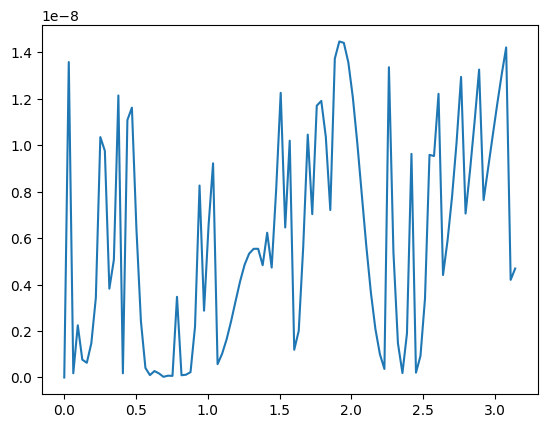

In [27]:
plt.plot(t_span, err_of_fid_exact_m3_dephased_to_m2_span)

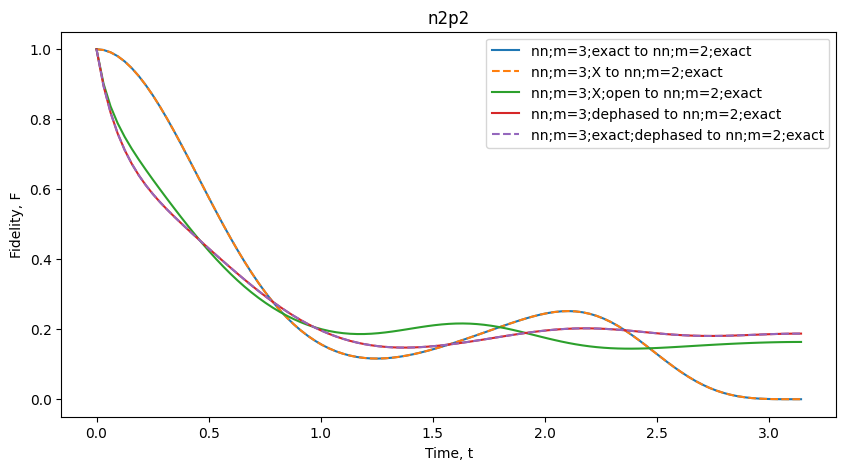

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(
    t_span,
    fid_hnn_m3_exact_respect_to_hnn_exact_m2_span,
    label=f"nn;m=3;exact to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m3_mesuared_by_x_respect_to_hnn_m2_exact_span,
    "--",
    label=f"nn;m=3;X to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_hnn_m3_open_mesuared_by_x_respect_to_hnn_m2_exact_span,
    label=f"nn;m=3;X;open to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_m3_dephased_to_m2_span,
    label=f"nn;m=3;dephased to nn;m=2;exact",
)
ax.plot(
    t_span,
    fid_exact_m3_dephased_to_m2_span,
    "--",
    label=f"nn;m=3;exact;dephased to nn;m=2;exact",
)

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, F")
ax.set_xlabel("Time, t")
ax.legend()

### Negativity

In [29]:
class SuperNumber:
    def __init__(self, *args):
        self._value = args

    def __eq__(self, other):
        return other in self._value


sn = SuperNumber(2, 3)

1 == sn, 2 == sn, 3 == sn

(False, True, True)

In [30]:
negativity_hnn_m3_mesuared_by_x_span = [
    qutip.entropy.negativity(s, sn)
    for s in tqdm(state_hnn_m3_mesuared_by_x_span, ncols=80)
]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 232.32it/s]


In [31]:
negativity_hnn_m3_open_mesuared_by_x_span = [
    qutip.entropy.negativity(s, sn)
    for s in tqdm(state_hnn_m3_open_mesuared_by_x_span, ncols=80)
]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 293.17it/s]


In [32]:
state_hnn_m3_exact_focked_span = [
    (s := entanglement_propagation.f_state(t, q3, m=3, n=n_bosons))
    / entanglement_propagation.f_state_norm(t, q3, m=3, n=n_bosons)
    for t in tqdm(t_span, ncols=80)
]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 303.19it/s]


In [33]:
negativity_hnn_m3_exact_focked_span = [
    qutip.entropy.negativity(qutip.ket2dm(s), 0, method="eigenvalues")
    for s in tqdm(state_hnn_m3_exact_focked_span, ncols=80)
]

100%|███████████████████████████████████████| 101/101 [00:00<00:00, 1925.07it/s]


In [34]:
negativity_hnn_m3_dephased_span, e = zip(
    *joblib.Parallel(n_jobs=16)(
        joblib.delayed(entanglement_propagation.negativity_of_dephased_state)(
            t, q3, m=3, n=n_bosons, gamma=0.01, quad_kwargs={"limit": 100}
        )
        for t in tqdm(t_span, ncols=80)
    )
)

100%|█████████████████████████████████████████| 101/101 [00:10<00:00,  9.56it/s]


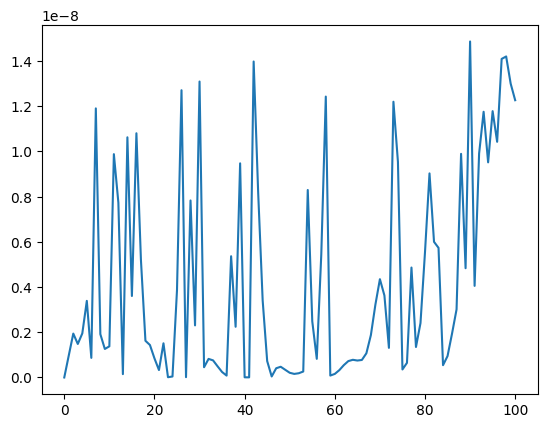

In [35]:
plt.plot(e)

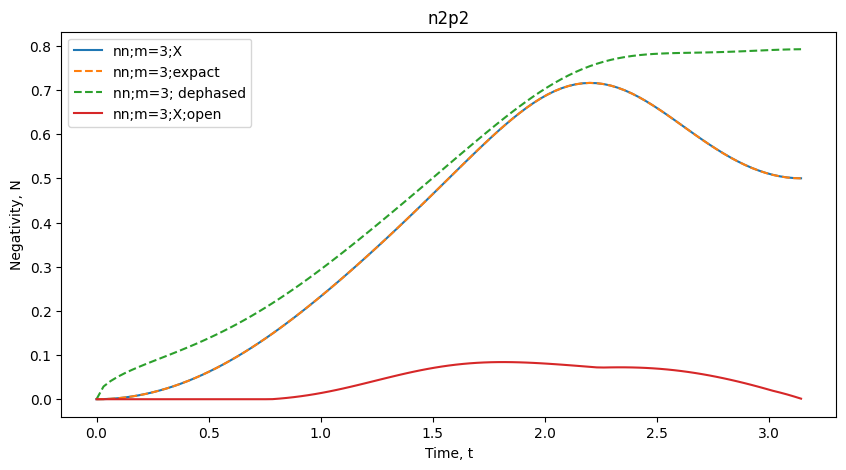

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(t_span, negativity_hnn_m3_mesuared_by_x_span, "-", label=f"nn;m=3;X")
ax.plot(t_span, negativity_hnn_m3_exact_focked_span, "--", label=f"nn;m=3;expact")
ax.plot(t_span, negativity_hnn_m3_dephased_span, "--", label=f"nn;m=3; dephased")
ax.plot(t_span, negativity_hnn_m3_open_mesuared_by_x_span, "-", label=f"nn;m=3;X;open")


ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Negativity, N")
ax.set_xlabel("Time, t")
ax.legend()

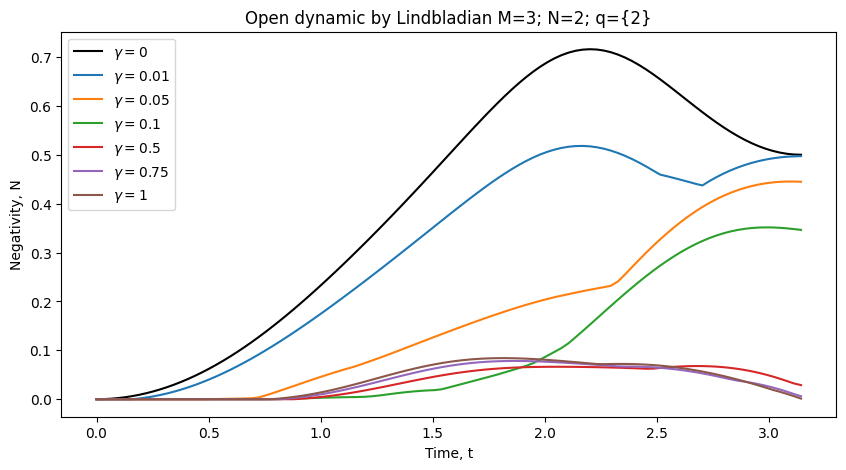

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(t_span, negativity_hnn_m3_mesuared_by_x_span, "-k", label=rf"$\gamma = 0$")

for gamma, state_hnn_m3_open_span in state_hnn_m3_open_span_by_gamma.items():
    _neg = [
        qutip.entropy.negativity(
            s, sn, 
            method="eigenvalues", 
            # logarithmic=True
        ) for s in state_hnn_m3_open_span]
    ax.plot(t_span, _neg, '-', label=rf"$\gamma = {gamma}$")

ax.set_title(f"Open dynamic by Lindbladian M=3; N={n_bosons}; q={{{i_projection}}}")
ax.set_ylabel("Negativity, N")
ax.set_xlabel("Time, t")
ax.legend()

## M = 4

In [36]:
n_bosons = 2
i_projection = n_bosons
q = [i_projection, i_projection]
model = bec.BEC_Qubits.init_default(n_bosons, 0)

In [37]:
init_state_m4 = (
    # np.prod([bec.coherent_state_constructor(model, n=m, k=i) for i in range(m)]) # 100x slowly
    math.prod(bec.coherent_state_constructor(model, n=4, k=i) for i in range(4))
    * bec.vacuum_state(model, n=4)
)

In [38]:
%time h_nn_m4 = sum((-1)**(i + 1) * bec.na(model, n=4, k=i) * bec.na(model, n=4, k=i+1) for i in range(3))

CPU times: user 5.63 ms, sys: 0 ns, total: 5.63 ms
Wall time: 5.42 ms


In [39]:
print(f"{math.prod(x**2 for x in h_nn_m4.dims[0]) * 8 / 1024 ** 3:.2} Gb")

0.32 Gb


In [40]:
t_span = np.linspace(0, np.pi, 101)

In [41]:
state_hnn_m4_span = qutip.sesolve(
    h_nn_m4, init_state_m4, t_span, progress_bar=TqdmProgressBar()
).states

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 449.38it/s]


In [42]:
c_ops_m4_key = "sz"
c_ops_m4_types = {
    "sz_chain": [sum(bec.sz(model, n=4, k=i) for i in [1, 2])],
    "sz": [sum(bec.sz(model, n=4, k=i) for i in range(4))],
    "sz_edges": [bec.sz(model, n=4, k=0) + bec.sz(model, n=4, k=3)],
}
c_ops_m4 = c_ops_m4_types[c_ops_m4_key]
options = qutip.Options(nsteps=1e8)

In [43]:
state_hnn_m4_open_span_cache_path = (
    f"../assets/open_dynamic-f_state-m4-n{n_bosons}-cops_{c_ops_m4_key}-tn{len(t_span)}"
)
try:
    state_hnn_m4_open_span = qutip.qload(state_hnn_m4_open_span_cache_path)
except FileNotFoundError:
    state_hnn_m4_open_solver = qutip.mesolve(
        h_nn_m4,
        init_state_m4,
        t_span,
        c_ops=c_ops_m4,
        options=options,
        progress_bar=TqdmProgressBar(),
    )
    state_hnn_m4_open_span = state_hnn_m4_open_solver.states
    qutip.qsave(state_hnn_m4_open_span, state_hnn_m4_open_span_cache_path)

In [44]:
measure_x_m4_i1 = bec.fock_x_state_constructor(model, n=4, i=1, k=i_projection)
measure_x_op_m4_i1 = measure_x_m4_i1 * measure_x_m4_i1.dag()

measure_x_m4_i2 = bec.fock_x_state_constructor(model, n=4, i=2, k=i_projection)
measure_x_op_m4_i2 = measure_x_m4_i2 * measure_x_m4_i2.dag()


def measure(state, operator):
    dim = len(state.dims[0])
    state_measured_unnormalized = qutip.ptrace(
        operator * state, [0, 1, dim - 2, dim - 1]
    )
    return state_measured_unnormalized / state_measured_unnormalized.tr()

In [45]:
state_hnn_m4_mesuared_by_x_span = joblib.Parallel(n_jobs=1)(
    joblib.delayed(measure)(s, measure_x_op_m4_i1 * measure_x_op_m4_i2)
    for s in tqdm(state_hnn_m4_span, ncols=80)
)

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 437.70it/s]


In [46]:
state_hnn_m4_open_mesuared_by_x_span = joblib.Parallel(n_jobs=1)(
    joblib.delayed(measure)(s, measure_x_op_m4_i1 * measure_x_op_m4_i2)
    for s in tqdm(state_hnn_m4_open_span, ncols=80)
)

100%|█████████████████████████████████████████| 101/101 [00:15<00:00,  6.68it/s]


In [47]:
fid_hnn_m4_open_mesuared_by_x_to_hnn_m4_mesuared_by_x_span = [
    qutip.metrics.fidelity(a / a.norm(), b / b.norm()) ** 2
    for a, b in tqdm(
        zip(state_hnn_m4_mesuared_by_x_span, state_hnn_m4_open_mesuared_by_x_span),
        total=len(state_hnn_m4_open_mesuared_by_x_span),
        ncols=80,
    )
]

100%|█████████████████████████████████████████| 101/101 [00:01<00:00, 96.12it/s]


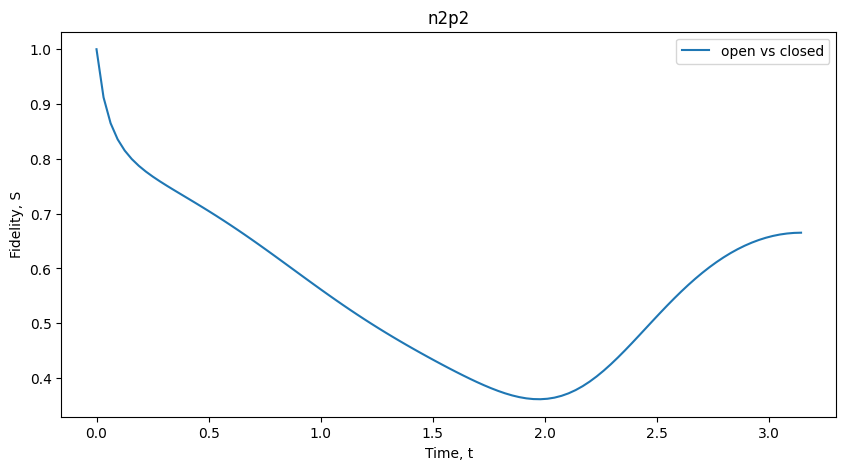

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(
    t_span,
    fid_hnn_m4_open_mesuared_by_x_to_hnn_m4_mesuared_by_x_span,
    label="open vs closed",
)

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()

In [49]:
fid_hnn_m4_respect_to_hnn_m2_exact_span = [
    entanglement_propagation.f_state_fid_respect_m2(t, q, 4, n_bosons)
    / entanglement_propagation.f_state_norm(t, q, 4, n_bosons) ** 2
    for t in tqdm(t_span, ncols=80)
]

100%|███████████████████████████████████████| 101/101 [00:00<00:00, 3092.67it/s]


In [50]:
%time state_hnn_m2_exact_span = [bec.state_under_h_nn_exact(model, t) for t in tqdm(t_span, ncols=80)]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 130.11it/s]

CPU times: user 777 ms, sys: 1.9 ms, total: 779 ms
Wall time: 777 ms


In [51]:
state_hnn_m4_exact_span = [
    entanglement_propagation.f_state(t, q, m=4, n=n_bosons, focked=False)
    / entanglement_propagation.f_state_norm(t, q, m=4, n=n_bosons)
    for t in tqdm(t_span, ncols=80)
]

100%|█████████████████████████████████████████| 101/101 [00:07<00:00, 14.33it/s]


In [52]:
fid_hnn_m4_exact_respect_to_hnn_exact_m2_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m4_exact_span, state_hnn_m2_exact_span),
        total=len(state_hnn_m4_exact_span),
        ncols=80,
    )
]

100%|██████████████████████████████████████| 101/101 [00:00<00:00, 33108.61it/s]


In [53]:
fid_hnn_m4_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m2_exact_span, state_hnn_m4_mesuared_by_x_span),
        total=len(state_hnn_m2_exact_span),
        ncols=80,
    )
]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 723.19it/s]


In [54]:
fid_hnn_m4_open_mesuared_by_x_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(a, b) ** 2
    for a, b in tqdm(
        zip(state_hnn_m2_exact_span, state_hnn_m4_open_mesuared_by_x_span),
        total=len(state_hnn_m2_exact_span),
        ncols=80,
    )
]

100%|████████████████████████████████████████| 101/101 [00:00<00:00, 714.06it/s]


In [ ]:
fid_hnn_m4_dephased_respect_to_hnn_m2_exact_span, e = zip(
    *[
        entanglement_propagation.fid_f_state_dephased_respect_m2(t, q, 4, n_bosons)
        for t in tqdm(t_span, ncols=80)
    ]
)

 90%|█████████████████████████████████████▊    | 91/101 [00:53<00:12,  1.28s/it]

In [ ]:
plt.plot(t_span, e)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# ax.plot(
#    t_span,
#    fid_hnn_m4_respect_to_hnn_m2_exact_span,
#    "o",
#    label=f"exact nn;m=4 to nn;m=2 ",
# )

ax.plot(
    t_span,
    fid_hnn_m4_exact_respect_to_hnn_exact_m2_span,
    label=f"nn;m=4;exact to nn;m=2;exact",
)
# ax.plot(
#    t_span,
#    fid_hnn_m4_mesuared_by_x_respect_to_hnn_m2_exact_span,
#    "--",
#    label=f"nn;m=4;X to nn;m=2;exact",
# )
ax.plot(
    t_span,
    fid_hnn_m4_open_mesuared_by_x_respect_to_hnn_m2_exact_span,
    "-g",
    label=f"nn;m=4;X;open to nn;m=2;exact",
)

ax.plot(
    t_span,
    fid_hnn_m4_dephased_respect_to_hnn_m2_exact_span,
    "-r",
    label=f"nn;m=4;dephased to nn;m=2;exact",
)

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()

### Сравнение дефазировной и обычной фиделити

In [ ]:
fid_m4_exact = [
    entanglement_propagation.f_state_fid_respect_m2(t, q, m=4, n=n_bosons)
    / entanglement_propagation.f_state_norm(t, q, m=4, n=n_bosons) ** 2
    for t in tqdm(t_span, ncols=80)
]

fid_m4_exact_phased_pi_1000 = [
    entanglement_propagation.f_state_fid_respect_m2(
        t, q, m=4, n=n_bosons, phase=np.pi / 1000
    )
    / entanglement_propagation.f_state_norm(t, q, m=4, n=n_bosons, phase=np.pi / 100)
    ** 2
    for t in tqdm(t_span, ncols=80)
]

fid_m4_exact_phased_pi_8 = [
    entanglement_propagation.f_state_fid_respect_m2(
        t, q, m=4, n=n_bosons, phase=np.pi / 8
    )
    / entanglement_propagation.f_state_norm(t, q, m=4, n=n_bosons, phase=np.pi / 8) ** 2
    for t in tqdm(t_span, ncols=80)
]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(t_span, fid_m4_exact, label=f"fid_m4_exact")
ax.plot(
    t_span,
    fid_m4_exact_phased_pi_1000,
    "--",
    label=f"fid_m4_exact_phased_pi_1000",
)
ax.plot(t_span, fid_m4_exact_phased_pi_8, "-.", label=f"fid_m4_exact_phased_pi_8")

ax.set_title(f"n{n_bosons}p{i_projection}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()

### Попытки поткрутить состояние вращением вокруг оси Z

In [ ]:
def rotation_around_z(phi):
    return (-1j * phi * (bec.sz(model, n=2, k=0) + bec.sz(model, n=2, k=1))).expm()


state_hnn_m4_open_mesuared_by_x_on_pi_rotated_span = [
    rotation_around_z(phi)
    * state_hnn_m4_open_mesuared_by_x_span[-1]
    * rotation_around_z(phi).conj()
    for phi in t_span * 4
]

In [ ]:
fid_hnn_m4_open_mesuared_by_x_on_pi_rotated_respect_to_hnn_m2_exact_span = [
    qutip.metrics.fidelity(state_hnn_m2_exact_span[-1], b) ** 2
    for b in tqdm(
        state_hnn_m4_open_mesuared_by_x_on_pi_rotated_span,
        total=len(state_hnn_m4_open_mesuared_by_x_on_pi_rotated_span),
        ncols=80,
    )
]

In [ ]:
plt.plot(
    t_span * 4, fid_hnn_m4_open_mesuared_by_x_on_pi_rotated_respect_to_hnn_m2_exact_span
)

## Сравнение дефазинга для разных длин цепочек

Assuming that the dephasing process produces a random phase

See PHYSICAL REVIEW A 90, 062336 (2014) Full-Bloch-sphere teleportation of spinor Bose-Einstein condensates and spin ensembles


In [ ]:
t_span = np.linspace(0, np.pi, 201)

In [ ]:
n_bosons_ = 3

In [ ]:
def fid_f_state_dephased_respect_m2(*args, gamma=1):
    t = args[0]
    if t == 0:
        return 1, 0

    def fun(phase):
        return (
            np.exp(-(phase**2) / (2 * gamma * t))
            * entanglement_propagation.f_state_fid_respect_m2(*args, phase=phase)
            / entanglement_propagation.f_state_norm(*args, phase=phase) ** 2
        )

    I, e = quad(fun, -np.inf, np.inf)
    return I / np.sqrt(2 * np.pi * gamma * t), e

In [ ]:
fids_by_m = dict()
for m in range(3, 7):
    f2, e = zip(
        *joblib.Parallel(n_jobs=n_jobs)(
            joblib.delayed(fid_f_state_dephased_respect_m2)(
                t, [n_bosons_] * (m - 2), m, n_bosons_
            )
            for t in tqdm(t_span, ncols=80)
        )
    )

    def f_state_fid_respect_m2_normilized(*args):
        return (
            entanglement_propagation.f_state_fid_respect_m2(*args)
            / entanglement_propagation.f_state_norm(*args) ** 2
        )

    f1 = joblib.Parallel(n_jobs=n_jobs)(
        joblib.delayed(f_state_fid_respect_m2_normilized)(
            t, [n_bosons_] * (m - 2), m, n_bosons_
        )
        for t in tqdm(t_span, ncols=80)
    )
    fids_by_m[m] = (f1, (f2, e))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for m, (f1, (f2, e)) in fids_by_m.items():
    print(np.abs(e).max())
    ax.plot(t_span, f1, label=f"m={m}")
    ax.plot(
        t_span,
        f2,
        "--",
        label=f"m={m};dephased",
    )

ax.set_title(f"n{n_bosons_}p{n_bosons_}")
ax.set_ylabel("Fidelity, S")
ax.set_xlabel("Time, t")
ax.legend()
ax.grid()

### Compare fidelities depend on $\gamma$

In [ ]:
t_span = np.linspace(0, np.pi, 201)

n_bosons_ = 3
m = 4
q = [n_bosons_] * m

In [ ]:
fid_without_dephasing = [
    entanglement_propagation.f_state_fid_respect_m2(t, q, m, n_bosons_)
    / entanglement_propagation.f_state_norm(t, q, m, n_bosons_) ** 2
    for t in t_span
]

In [70]:
fids_by_gamma = dict()
for gamma in [0.001, 0.05, 0.1, 0.5, 0.75, 1]:
    f, e = zip(
        *joblib.Parallel(n_jobs=n_jobs)(
            joblib.delayed(entanglement_propagation.fid_f_state_dephased_respect_m2)(
                t, [n_bosons_] * (m - 2), m, n_bosons_, gamma
            )
            for t in tqdm(t_span, ncols=80, postfix=f"g={gamma}")
        )
    )
    fids_by_gamma[gamma] = (f, e)

 80%|███████████████████████████       | 160/201 [00:53<00:19,  2.06it/s, g=0.5]/home/kephircheek/Projects/RSF-Entanglement-Generation-between-BEC/Entanglement-propagation-with-bec-qubits/research-emqwuqoc-chain/libs/entanglement_propagation.py:253: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  I, e = quad(fun, -np.inf, np.inf)
/home/kephircheek/Projects/RSF-Entanglement-Generation-between-BEC/Entanglement-propagation-with-bec-qubits/research-emqwuqoc-chain/libs/entanglement_propagation.py:253: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If inc

1.4298527775006631e-08
1.476296571929667e-08
1.4883611768792308e-08
4.215155086369729e-08
6.816356753218351e-07
6.69827673208541e-06


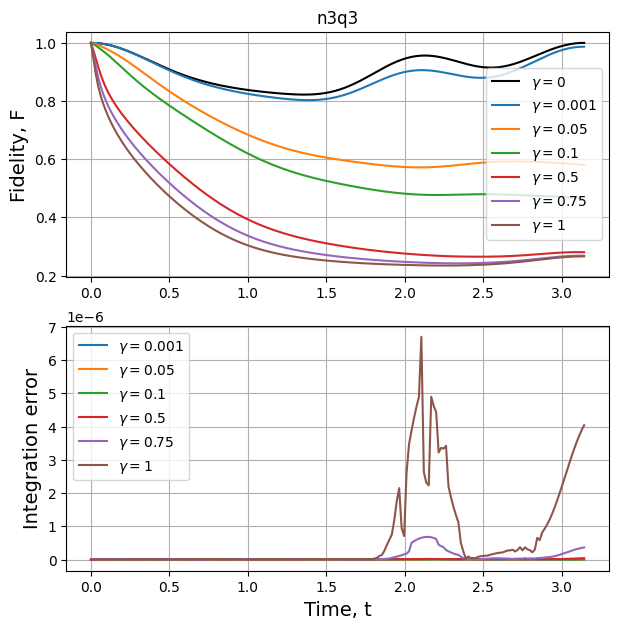

In [71]:
fontsize = 14
figsize = (7, 7)

fig, axes = plt.subplots(2, 1, figsize=figsize)

axes[0].plot(
    t_span,
    fid_without_dephasing,
    "-k",
    label=r"$\gamma=0$",
)

for gamma, (f, e) in fids_by_gamma.items():
    print(np.abs(e).max())
    axes[0].plot(t_span, f, "-", label=rf"$\gamma={gamma}$")
    axes[1].plot(t_span, e, "-", label=rf"$\gamma={gamma}$")

for i, ax in enumerate(axes):
    if i == 0:
        ax.set_title(f"n{n_bosons_}q{n_bosons_}")
    if i == 0:
        ax.set_ylabel("Fidelity, F", fontsize=fontsize)
    else:
        ax.set_ylabel("Integration error", fontsize=fontsize)
    if i == 1:
        ax.set_xlabel("Time, t", fontsize=fontsize)
    ax.legend()
    ax.grid()